In [16]:
import os
import re
import math
import torch
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from gidd.eval.generation_info import GenerationInfoHandler
from datasets import load_from_disk

mask_token_id = 9

In [17]:
# Load data

base_dir = "generation_info"
num_dirs = len([name for name in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, name))])
combination_row_ids = [i + 1 for i in range(num_dirs)]

dir_path_dict = {}
meta_dict = {}
history_dict = {}
logits_dict = {}
confidence_t_0_dict = {}
marginals_dict = {}
change_events_table_dict = {}
forward_calls_dict = {}
prune_correct_dict = {}
beam_search_forward_calls_dict = {}
beam_search_branch_correctness_dict = {}
beam_search_beam_correctness_dict = {}
denoise_config_dict = {}
combination_rows = []

for combination_row in combination_row_ids:
    dir_path = f"{base_dir}/combination_{combination_row}"
    meta, history, logits, confidence_t_0, marginals, change_events_table, forward_calls, prune_correct, beam_search_forward_calls, beam_search_branch_correctness, beam_search_beam_correctness = GenerationInfoHandler.load_all(dir_path)
    dir_path_dict[combination_row] = dir_path
    meta_dict[combination_row] = meta
    history_dict[combination_row] = history
    logits_dict[combination_row] = logits
    confidence_t_0_dict[combination_row] = confidence_t_0
    marginals_dict[combination_row] = marginals
    change_events_table_dict[combination_row] = change_events_table
    forward_calls_dict[combination_row] = forward_calls
    prune_correct_dict[combination_row] = prune_correct
    beam_search_forward_calls_dict[combination_row] = beam_search_forward_calls
    beam_search_branch_correctness_dict[combination_row] = beam_search_branch_correctness
    beam_search_beam_correctness_dict[combination_row] = beam_search_beam_correctness
    denoise_config_dict[combination_row] = meta['sampling_strategy']['p_denoise']

    sampling_parameters = meta['sampling_strategy'].copy()
    if isinstance(sampling_parameters.get('p_denoise', None), dict):
        for k, v in sampling_parameters['p_denoise'].items():
            sampling_parameters[f'p_denoise_{k}'] = v
        del sampling_parameters['p_denoise']
    sampling_parameters['combination_row'] = combination_row
    combination_rows.append(sampling_parameters)

combinations_df = pd.DataFrame(combination_rows)

print(meta_dict[combination_row_ids[0]])

{'accuracy': 0.7109375, 'correctly_filled_cells': 0.870693588256836, 'nfe': 101.1703109741211, 'time_taken_s': 888.855092048645, 'speed_samples_per_s': 0.720027376481491, 'created_at': '2025-11-17 00:44:47 GMT', 'num_samples': 640, 'max_seq_len': 81, 'collect_history': False, 'collect_logits': False, 'collect_confidence_t_0': False, 'collect_marginals': False, 'collect_change_events': False, 'collect_forward_calls': False, 'collect_prune_correct': True, 'collect_beam_search_forward_calls': True, 'collect_beam_search_branch_correctness': False, 'collect_beam_search_beam_correctness': True, 'general_sampling': {'device': 0, 'seed': 1, 'checkpoint': 'checkpoints/gidd_0_2/300_epochs', 'dataset': 'hard', 'num_samples': 640, 'num_denoising_steps': 80, 'num_self_correction_steps': 0, 'batch_size': 1, 'min_p': 0.0, 'compile_torch': 0, 'combinations_row': 1}, 'sampling_strategy': {'strategy': 'gidd_change_low_confidence_positions', 'time_steps': 'inferred', 'score_mask_position': 'MDM_max', 'sc

In [18]:
# Sum up events across all samples, the combine combinations into df
events = []
for current_combination_row in combination_row_ids:
    current_meta = meta_dict[current_combination_row]
    beam_search_meta = current_meta['beam_search']
    strategy = current_meta['sampling_strategy']['strategy']
    num_beams = beam_search_meta['pruning_num_beams']
    branching_factor = beam_search_meta['branching_factor']
    beam_search_beam_correctness_events = beam_search_beam_correctness_dict[current_combination_row]
    total_events = {}
    for event in beam_search_beam_correctness_events:
        for k, v in event.items():
            if k not in total_events:
                total_events[k] = 0
            total_events[k] += v
    events.append({**total_events,
                   'combination_row': current_combination_row,
                   'strategy': strategy,
                   'num_beams': num_beams,
                   'branching_factor': branching_factor,
                   })
events_df = pd.DataFrame(events)
events_df.head()

,bad_branch,good_branch,bad_intermediate_propagation,good_intermediate_propagation,bad_propagation,good_propagation,bad_pruning_branches_missed,bad_pruning_instances,combination_row,strategy,num_beams,branching_factor
0,7,10,210,44,187,21,22,22,1,gidd_change_low_confidence_positions,1,2
1,7,5,185,11,185,9,11,11,2,gidd_change_based_on_model_confidence_to_change,1,2
2,8,3,182,13,181,9,11,11,3,gidd_prob_to_recover_data,1,2
3,3,0,177,0,177,0,18,18,4,mdlm_adaptive_score_select_update,1,2
4,8,28,258,98,194,35,20,20,5,gidd_change_low_confidence_positions,2,2


In [19]:
events_df = events_df.sort_values(by=['strategy', 'num_beams', 'branching_factor'])
# events_df = events_df.sort_values(by=['num_beams', 'branching_factor', 'strategy'])
events_df[['strategy', 'num_beams', 'branching_factor', 'bad_branch', 'good_branch', 'bad_propagation', 'good_propagation', 'bad_pruning_branches_missed', 'bad_pruning_instances']]

,strategy,num_beams,branching_factor,bad_branch,good_branch,bad_propagation,good_propagation,bad_pruning_branches_missed,bad_pruning_instances
1,gidd_change_based_on_model_confidence_to_change,1,2,7,5,185,9,11,11
5,gidd_change_based_on_model_confidence_to_change,2,2,8,10,187,18,1,1
9,gidd_change_based_on_model_confidence_to_change,2,4,3,10,161,11,31,29
13,gidd_change_based_on_model_confidence_to_change,4,4,4,18,162,19,10,9
0,gidd_change_low_confidence_positions,1,2,7,10,187,21,22,22
4,gidd_change_low_confidence_positions,2,2,8,28,194,35,20,20
8,gidd_change_low_confidence_positions,2,4,3,16,165,45,62,55
12,gidd_change_low_confidence_positions,4,4,4,44,174,79,79,56
2,gidd_prob_to_recover_data,1,2,8,3,181,9,11,11
6,gidd_prob_to_recover_data,2,2,9,7,183,18,1,1


In [20]:
events_df = events_df.sort_values(by=['strategy', 'num_beams', 'branching_factor'])
# events_df = events_df.sort_values(by=['num_beams', 'branching_factor', 'strategy'])
# events_df[['strategy', 'num_beams', 'branching_factor', 'bad_branch', 'bad_propagation', 'bad_pruning_instances']]
events_df[['strategy', 'num_beams', 'branching_factor', 'bad_branch', 'bad_propagation', 'bad_pruning_branches_missed']]

,strategy,num_beams,branching_factor,bad_branch,bad_propagation,bad_pruning_branches_missed
1,gidd_change_based_on_model_confidence_to_change,1,2,7,185,11
5,gidd_change_based_on_model_confidence_to_change,2,2,8,187,1
9,gidd_change_based_on_model_confidence_to_change,2,4,3,161,31
13,gidd_change_based_on_model_confidence_to_change,4,4,4,162,10
0,gidd_change_low_confidence_positions,1,2,7,187,22
4,gidd_change_low_confidence_positions,2,2,8,194,20
8,gidd_change_low_confidence_positions,2,4,3,165,62
12,gidd_change_low_confidence_positions,4,4,4,174,79
2,gidd_prob_to_recover_data,1,2,8,181,11
6,gidd_prob_to_recover_data,2,2,9,183,1


In [21]:
strategy_to_label = {
    'mdlm_adaptive_score_select_update': 'MD top-k probability',
    'gidd_change_based_on_model_confidence_to_change': 'Mask current token',
    'gidd_change_low_confidence_positions': 'Fix low-confidence tokens',
}

In [ ]:
def plot_bad_events_by_strategy(strategy_name):
    """
    Plot bad events (bad_branch, bad_propagation, bad_pruning_branches_missed) 
    for different num_beams/branching_factor combinations for a given strategy.
    """
    # Filter data for the specified strategy
    strategy_data = events_df[events_df['strategy'] == strategy_name].copy()
    
    if len(strategy_data) == 0:
        print(f"No data found for strategy: {strategy_name}")
        print(f"Available strategies: {events_df['strategy'].unique()}")
        return
    
    # Create a combination label for x-axis
    strategy_data['beam_config'] = strategy_data['num_beams'].astype(str) + '/' + strategy_data['branching_factor'].astype(str)
    
    # Sort by num_beams and branching_factor for consistent ordering
    strategy_data = strategy_data.sort_values(['num_beams', 'branching_factor'])
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x_positions = range(len(strategy_data))
    width = 0.25
    
    # Plot each type of bad event
    ax.bar([x - width for x in x_positions], strategy_data['bad_branch'], width, 
           label='Bad Branches', alpha=0.8, color='red')
    ax.bar(x_positions, strategy_data['bad_propagation'], width, 
           label='Bad Propagations', alpha=0.8, color='orange')
    ax.bar([x + width for x in x_positions], strategy_data['bad_pruning_branches_missed'], width, 
           label='Bad Pruning', alpha=0.8, color='darkred')
    
    # Customize the plot
    ax.set_xlabel('Num Beams / Branching Factor')
    ax.set_ylabel('Number of Events')
    ax.set_title(f'Bad Events by Beam Configuration - Strategy: {strategy_name}')
    ax.set_xticks(x_positions)
    ax.set_xticklabels(strategy_data['beam_config'], rotation=45)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Also display the data table for reference
    display_columns = ['num_beams', 'branching_factor', 'bad_branch', 'bad_propagation', 'bad_pruning_branches_missed']
    print(f"\nData for strategy '{strategy_name}':")
    print(strategy_data[display_columns].to_string(index=False))

# Example usage - you can change the strategy name as needed
available_strategies = events_df['strategy'].unique()
print("Available strategies:", available_strategies)
print("\nTo plot for a specific strategy, call:")
print("plot_bad_events_by_strategy('your_strategy_name')")

# Uncomment the line below and replace with your desired strategy to plot
# plot_bad_events_by_strategy('your_strategy_name')

Available strategies: ['gidd_change_based_on_model_confidence_to_change'
 'gidd_change_low_confidence_positions' 'gidd_prob_to_recover_data'
 'mdlm_adaptive_score_select_update']

To plot for a specific strategy, call:
plot_bad_events_by_strategy('your_strategy_name')


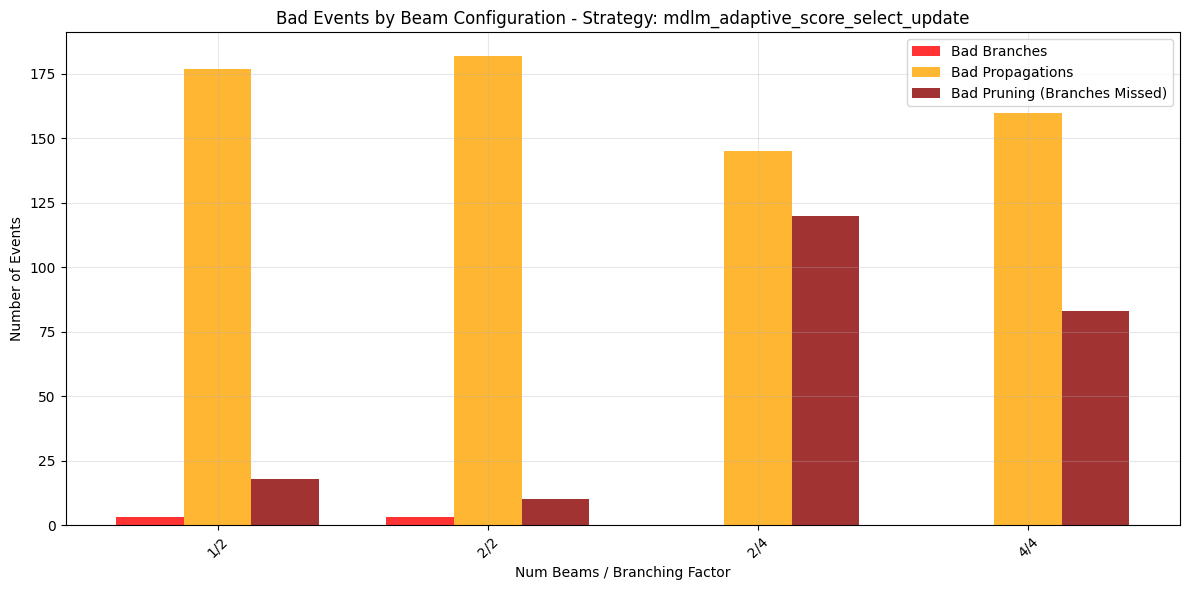


Data for strategy 'mdlm_adaptive_score_select_update':
 num_beams  branching_factor  bad_branch  bad_propagation  bad_pruning_branches_missed
         1                 2           3              177                           18
         2                 2           3              182                           10
         2                 4           0              145                          120
         4                 4           0              160                           83


In [23]:
plot_bad_events_by_strategy('mdlm_adaptive_score_select_update')

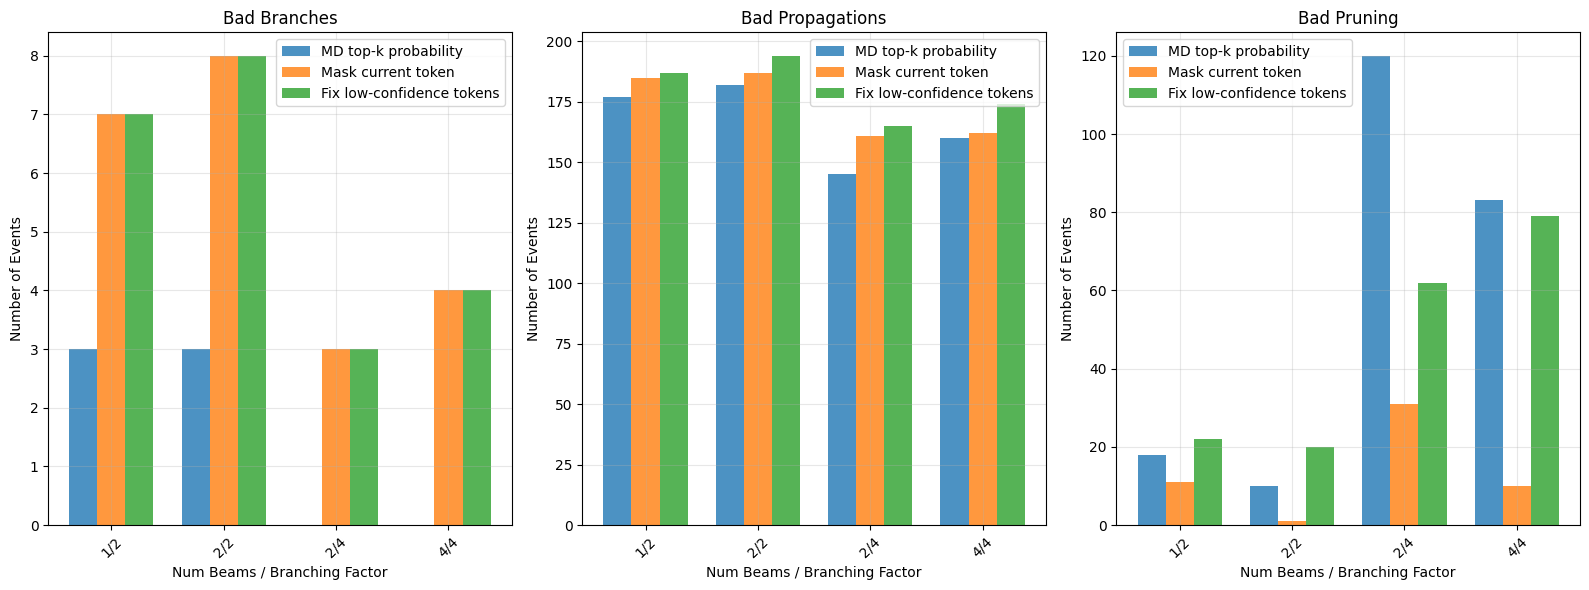


Summary table for all strategies:
           strategy_label  num_beams  branching_factor  bad_branch  bad_propagation  bad_pruning_branches_missed
       Mask current token          1                 2           7              185                           11
Fix low-confidence tokens          1                 2           7              187                           22
     MD top-k probability          1                 2           3              177                           18
       Mask current token          2                 2           8              187                            1
Fix low-confidence tokens          2                 2           8              194                           20
     MD top-k probability          2                 2           3              182                           10
       Mask current token          2                 4           3              161                           31
Fix low-confidence tokens          2                 4       

In [29]:
def compare_strategies_bad_events():
    """
    Compare bad events across the three main strategies in a single plot.
    """
    strategies_to_compare = [
        'mdlm_adaptive_score_select_update',
        'gidd_change_based_on_model_confidence_to_change', 
        'gidd_change_low_confidence_positions'
    ]
    
    # Filter data for the specified strategies
    comparison_data = events_df[events_df['strategy'].isin(strategies_to_compare)].copy()
    
    if len(comparison_data) == 0:
        print("No data found for the specified strategies")
        return
    
    # Create a combination label for x-axis
    comparison_data['beam_config'] = comparison_data['num_beams'].astype(str) + '/' + comparison_data['branching_factor'].astype(str)
    
    # Sort by num_beams and branching_factor for consistent ordering
    comparison_data = comparison_data.sort_values(['num_beams', 'branching_factor', 'strategy'])
    
    # Get unique beam configurations
    beam_configs = comparison_data['beam_config'].unique()
    
    # Create subplots for each type of bad event
    fig, axes = plt.subplots(1, 3, figsize=(16, 6))
    # fig.suptitle('Bad Events Comparison Across Strategies', fontsize=16)
    
    event_types = ['bad_branch', 'bad_propagation', 'bad_pruning_branches_missed']
    # event_labels = ['Bad Branches', 'Bad Propagations', 'Bad Pruning (Branches Missed)']
    event_labels = ['Bad Branches', 'Bad Propagations', 'Bad Pruning']
    colors = ['red', 'orange', 'darkred']
    
    for i, (event_type, event_label, color) in enumerate(zip(event_types, event_labels, colors)):
        ax = axes[i]
        
        # Create grouped bar chart
        x_positions = np.arange(len(beam_configs))
        width = 0.25
        
        for j, strategy in enumerate(strategies_to_compare):
            strategy_data = comparison_data[comparison_data['strategy'] == strategy]
            
            # Ensure we have data for all beam configs (fill with 0 if missing)
            values = []
            for config in beam_configs:
                config_data = strategy_data[strategy_data['beam_config'] == config]
                if len(config_data) > 0:
                    values.append(config_data[event_type].iloc[0])
                else:
                    values.append(0)
            
            # Use strategy labels from the mapping
            strategy_label = strategy_to_label.get(strategy, strategy)
            
            ax.bar(x_positions + j * width, values, width, 
                   label=strategy_label, alpha=0.8)
        
        ax.set_xlabel('Num Beams / Branching Factor')
        ax.set_ylabel('Number of Events')
        ax.set_title(event_label)
        ax.set_xticks(x_positions + width)
        ax.set_xticklabels(beam_configs, rotation=45)
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Display summary table
    print("\nSummary table for all strategies:")
    summary_columns = ['strategy', 'num_beams', 'branching_factor', 'bad_branch', 'bad_propagation', 'bad_pruning_branches_missed']
    summary_data = comparison_data[summary_columns].copy()
    summary_data['strategy_label'] = summary_data['strategy'].map(strategy_to_label)
    display_columns = ['strategy_label', 'num_beams', 'branching_factor', 'bad_branch', 'bad_propagation', 'bad_pruning_branches_missed']
    print(summary_data[display_columns].to_string(index=False))

# Call the function to generate the comparison plot
compare_strategies_bad_events()